In [1]:
dir.create("../../results/mofa/figures/", showWarnings = FALSE, recursive = TRUE)
options(repr.plot.width = 9, repr.plot.height = 6, repr.plot.res = 150)
knitr::opts_chunk$set(warning = FALSE, message = FALSE)

## Overview

This notebook characterises each latent factor:
1. **Variance decomposition** — how much does each factor explain per view?
2. **Factor scatter plots** — coloured by IGHV mutation status and trisomy 12
3. **Factor–covariate associations** — systematic correlation with all clinical variables

The central question: *did MOFA+ recover known CLL biology (IGHV, trisomy 12)
without any supervision?*

---

## Setup

In [2]:
library(MOFA2)
library(ggplot2)
library(dplyr)
library(tidyr)
library(purrr)
library(pheatmap)
library(cowplot)
library(ggrepel)
library(RColorBrewer)

theme_set(theme_bw(base_size = 12))

ighv_colors    <- c(M = "#4DAF4A", U = "#E41A1C")
trisomy_colors <- c(No = "#f7f7f7", Yes = "#7570b3")

MOFAobject <- readRDS("../../results/mofa/CLL_MOFA_annotated.RDS")
meta       <- samples_metadata(MOFAobject)

cat("Factors:", get_dimensions(MOFAobject)$K,
    "| Samples:", nrow(meta), "\n")


Attaching package: ‘MOFA2’




The following object is masked from ‘package:stats’:

    predict





Attaching package: ‘dplyr’




The following objects are masked from ‘package:stats’:

    filter, lag




The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




Factors: 10 | Samples: 200 


---

## 1. Variance Decomposition Heatmap

[[1]]

[[2]]


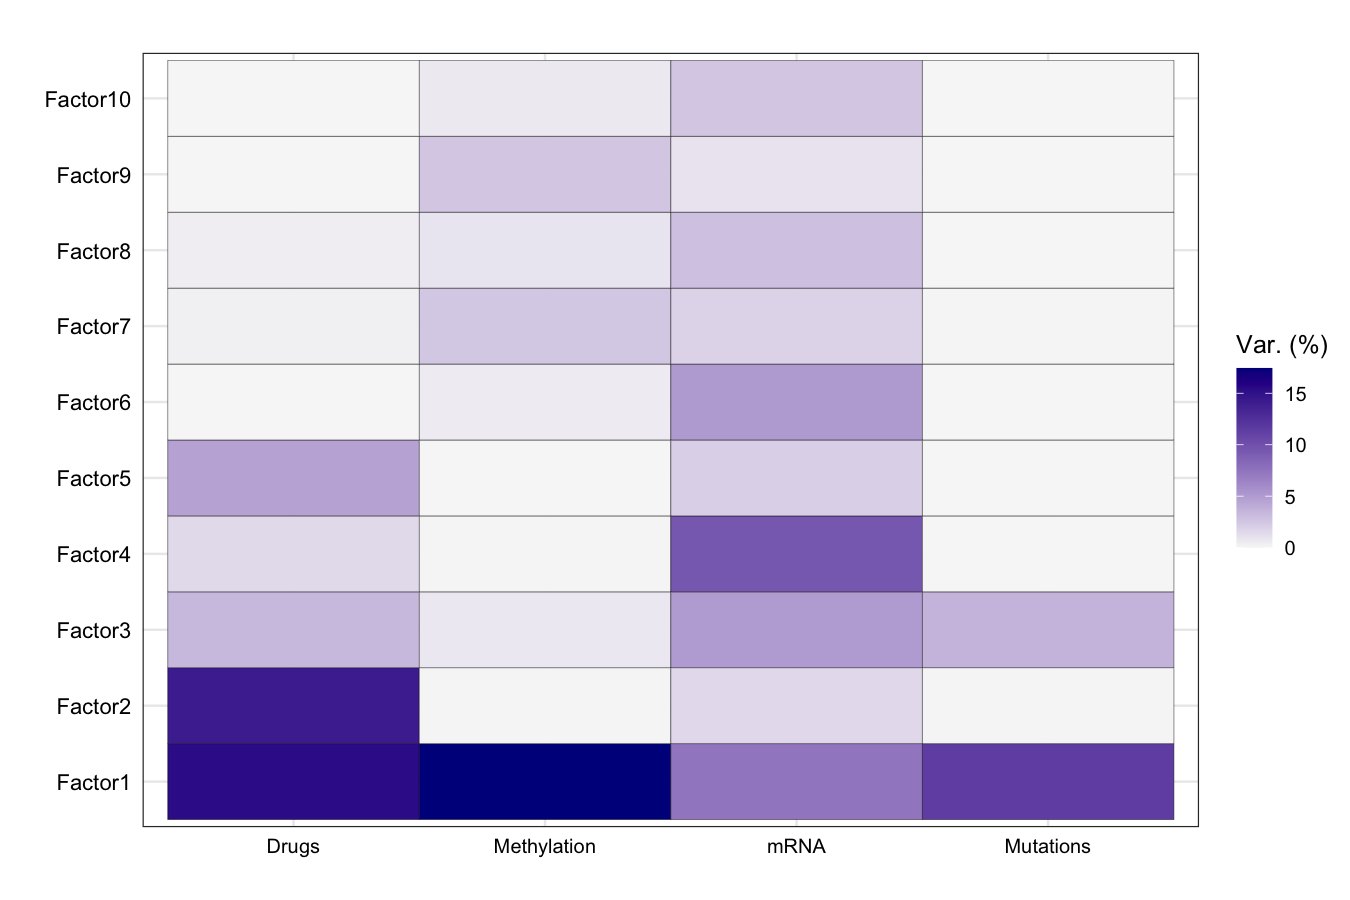

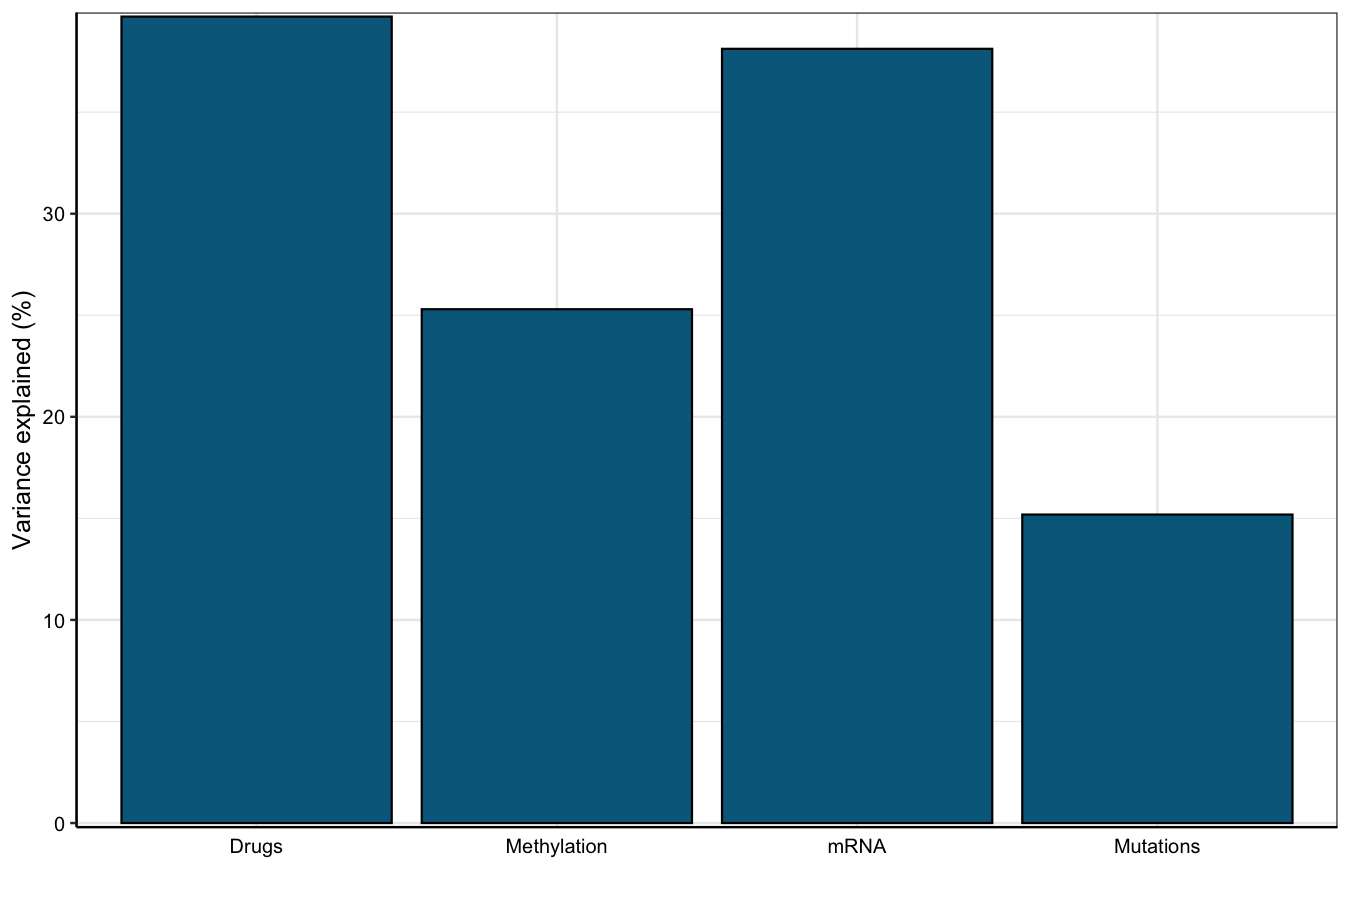

In [3]:
# This is MOFA+'s primary output: the R² explained by each factor (rows)
# in each view (columns).
#
# Interpretation:
#   High R² in MULTIPLE views → "shared factor" = coordinated biology
#     visible across platforms (e.g., IGHV drives both RNA and methylation)
#   High R² in ONE view only → "view-specific factor" = biology or
#     technical variation unique to that assay
#
# The marginal column (right) shows total variance explained per view.

plot_variance_explained(
  MOFAobject,
  x          = "view",
  y          = "factor",
  plot_total = TRUE
)

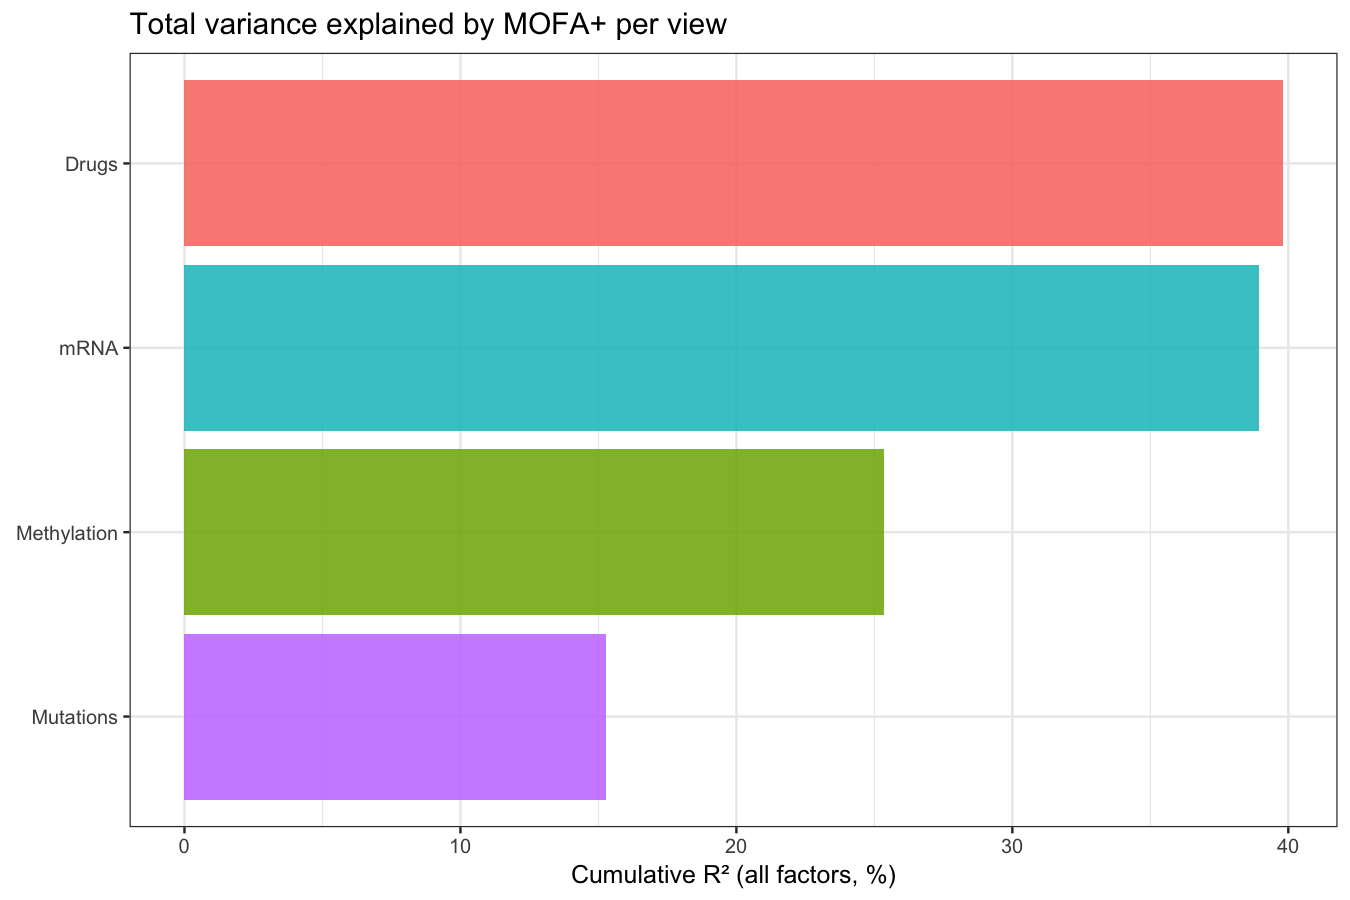

In [4]:
# Total R² per view: which platforms are best captured by the MOFA model?
# Low total R² in a view may indicate noise, non-linear variation, or
# that the number of factors was insufficient for that view.

r2_mat <- get_variance_explained(MOFAobject)$r2_per_factor[[1]]

as.data.frame(r2_mat) |>
  tibble::rownames_to_column("factor") |>
  tidyr::pivot_longer(-factor, names_to = "view", values_to = "r2") |>
  dplyr::filter(!is.na(r2)) |>
  dplyr::group_by(view) |>
  dplyr::summarise(total_r2 = sum(r2)) |>
  ggplot(aes(x = reorder(view, total_r2), y = total_r2, fill = view)) +
  geom_col(show.legend = FALSE, alpha = 0.85) +
  coord_flip() +
  labs(
    title = "Total variance explained by MOFA+ per view",
    x = NULL, y = "Cumulative R² (all factors, %)"
  )

---

## 2. Factor Scatter Plots Coloured by IGHV Status

Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's colour values.”


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'MOFA+ Factor 1 vs Factor 2 — CLL patient landscape' in 'mbcsToSbcs': dot substituted for <e2>”


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'MOFA+ Factor 1 vs Factor 2 — CLL patient landscape' in 'mbcsToSbcs': dot substituted for <80>”


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'MOFA+ Factor 1 vs Factor 2 — CLL patient landscape' in 'mbcsToSbcs': dot substituted for <94>”


Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'MOFA+ Factor 1 vs Factor 2 — CLL patient landscape' in 'mbcsToSbcs': dot substituted for <e2>”


Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'MOFA+ Factor 1 vs Factor 2 — CLL patient landscape' in 'mbcsToSbcs': dot substituted for <80>”


Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'MOFA+ Factor 1 vs Factor 2 — CLL patient landscape' in 'mbcsToSbcs': dot substituted for <94>”


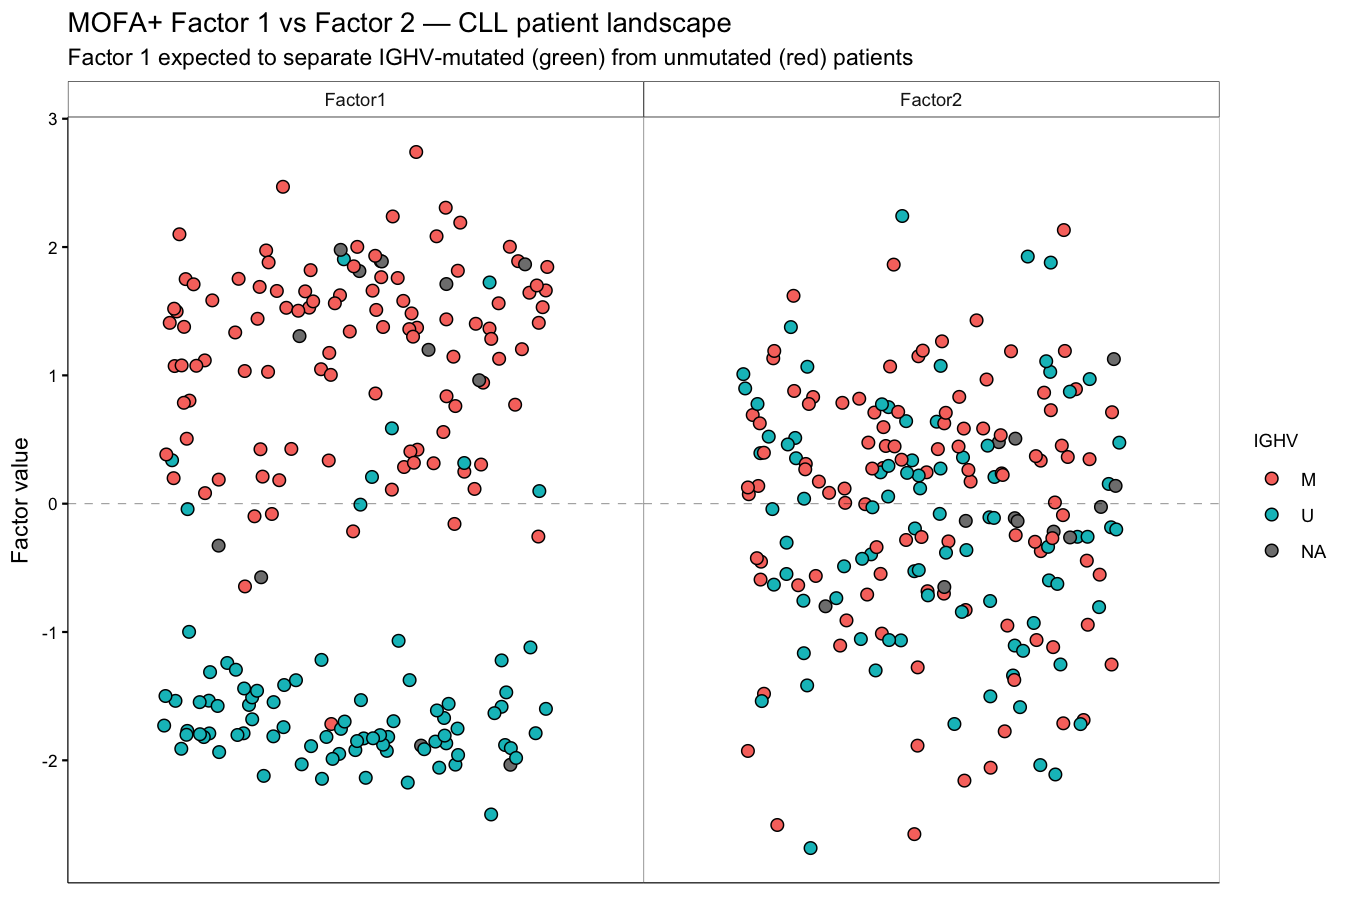

In [5]:
# Factor 1 vs Factor 2 — the primary axes of CLL heterogeneity.
# Colouring by IGHV status tests whether MOFA+ independently recovered
# the most important clinical prognostic marker without ever seeing labels.
#
# Expected result: Factor 1 cleanly separates M (mutated) from U (unmutated).
# This would demonstrate that the multi-omics signature of IGHV status
# is recoverable by unsupervised integration.

plot_factor(
  MOFAobject,
  factor   = c(1, 2),
  color_by  = "IGHV",
  dot_size  = 2.5,
  legend   = TRUE
) +
  scale_colour_manual(values = ighv_colors,
    labels = c(M = "Mutated — indolent", U = "Unmutated — aggressive"),
    na.value = "grey70"
  ) +
  labs(
    title    = "MOFA+ Factor 1 vs Factor 2 — CLL patient landscape",
    subtitle = "Factor 1 expected to separate IGHV-mutated (green) from unmutated (red) patients",
    colour   = "IGHV status"
  )

Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's colour values.”


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'MOFA+ Factor 1 vs Factor 2 — coloured by trisomy 12' in 'mbcsToSbcs': dot substituted for <e2>”


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'MOFA+ Factor 1 vs Factor 2 — coloured by trisomy 12' in 'mbcsToSbcs': dot substituted for <80>”


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'MOFA+ Factor 1 vs Factor 2 — coloured by trisomy 12' in 'mbcsToSbcs': dot substituted for <94>”


Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'MOFA+ Factor 1 vs Factor 2 — coloured by trisomy 12' in 'mbcsToSbcs': dot substituted for <e2>”


Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'MOFA+ Factor 1 vs Factor 2 — coloured by trisomy 12' in 'mbcsToSbcs': dot substituted for <80>”


Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'MOFA+ Factor 1 vs Factor 2 — coloured by trisomy 12' in 'mbcsToSbcs': dot substituted for <94>”


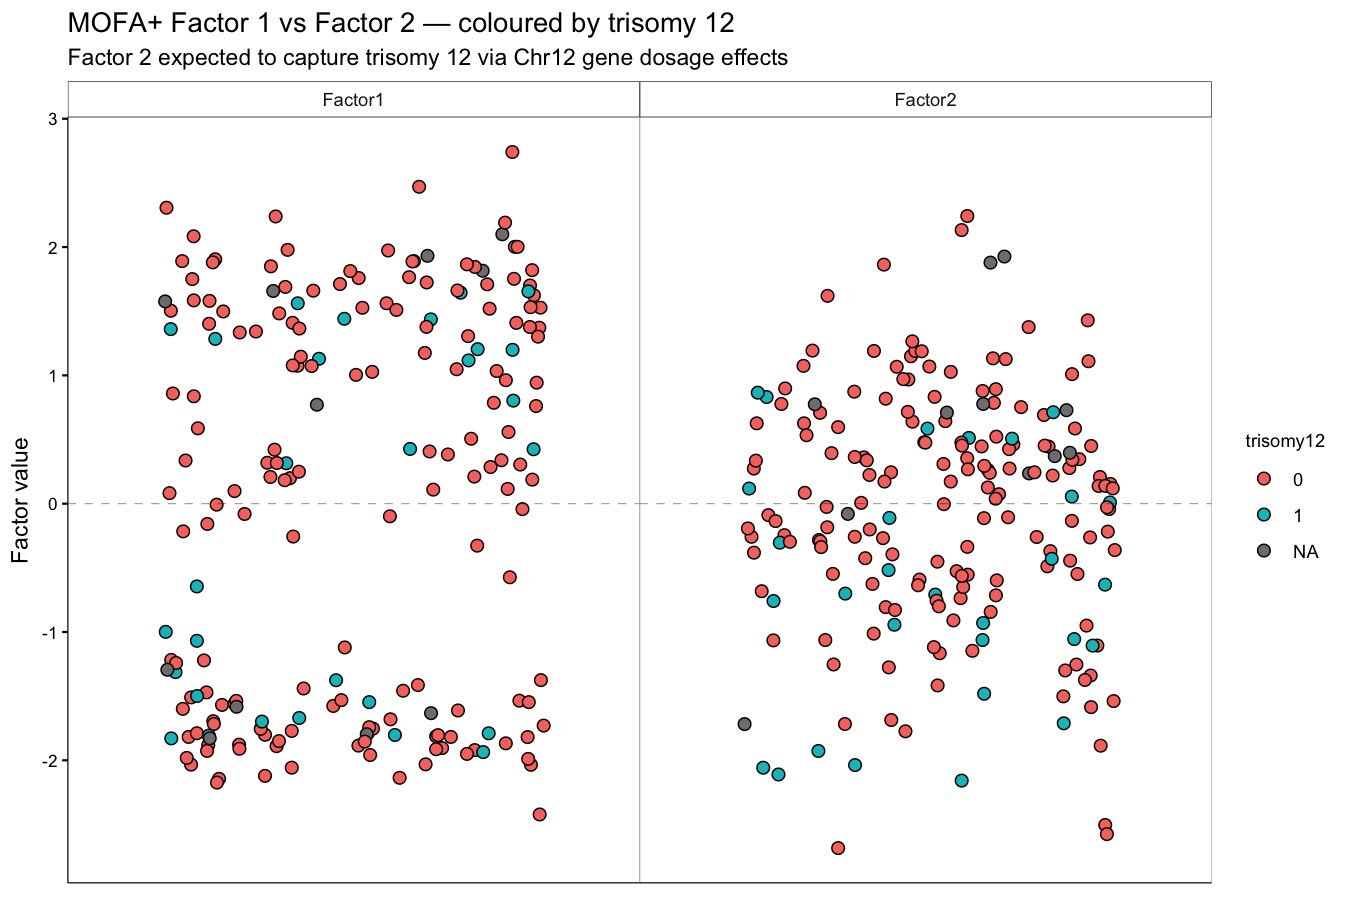

In [6]:
# Factor 2 is often driven by trisomy 12 — the most common chromosomal
# aberration in CLL, present in ~15% of patients. Trisomy 12 drives
# a distinct transcriptional programme through gene dosage effects.

plot_factor(
  MOFAobject,
  factor   = c(1, 2),
  color_by  = "trisomy12",
  dot_size  = 2.5,
  legend   = TRUE
) +
  scale_colour_manual(
    values   = c("0" = "grey80", "1" = "#7570b3"),
    labels   = c("0" = "No trisomy 12", "1" = "Trisomy 12"),
    na.value = "grey50"
  ) +
  labs(
    title    = "MOFA+ Factor 1 vs Factor 2 — coloured by trisomy 12",
    subtitle = "Factor 2 expected to capture trisomy 12 via Chr12 gene dosage effects",
    colour   = "Trisomy 12"
  )

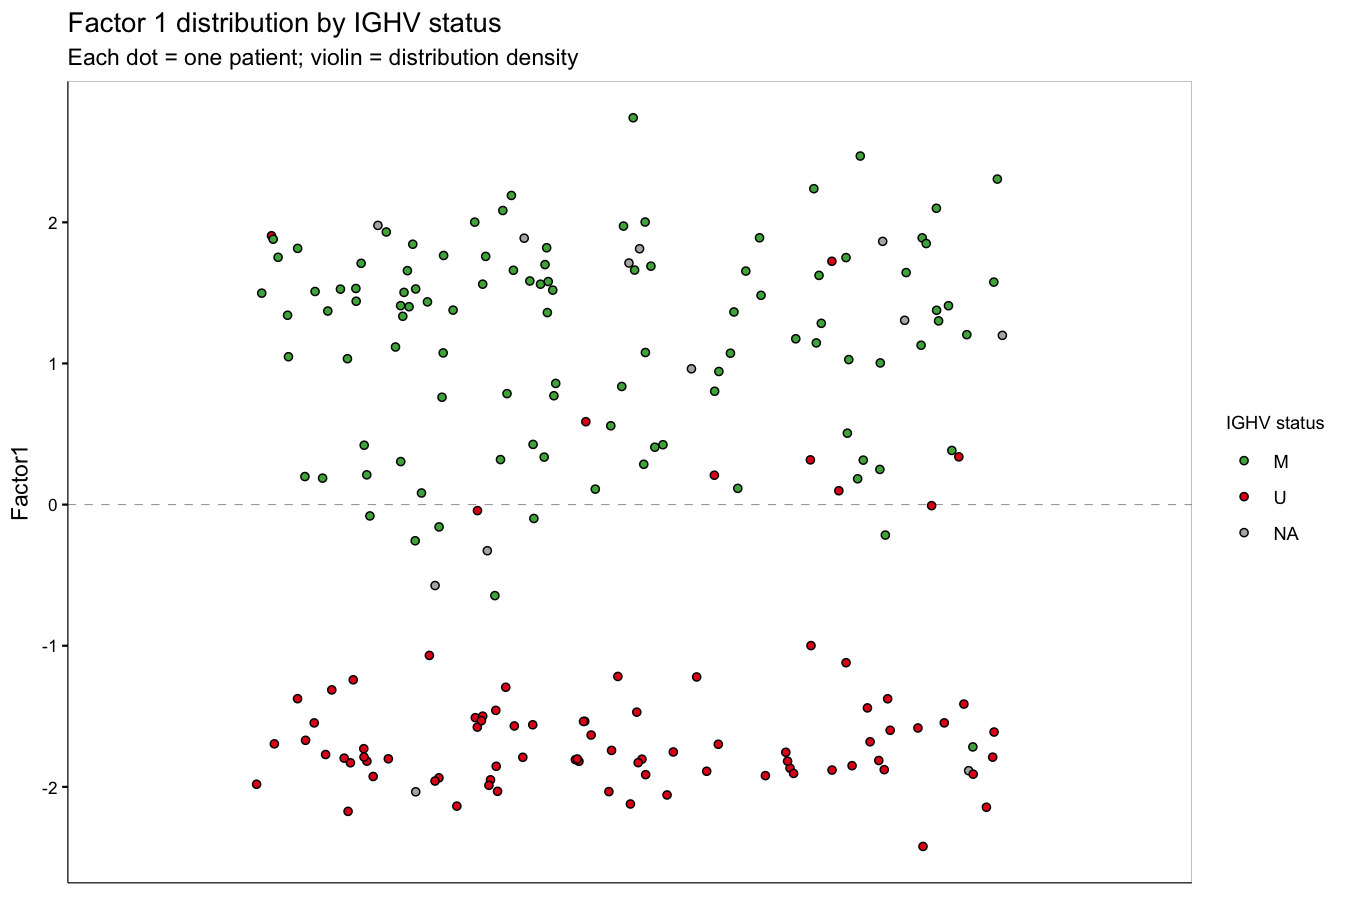

In [7]:
# Violin + jitter plot of Factor 1 stratified by IGHV status.
# A statistically significant separation confirms Factor 1 quantifies IGHV.

plot_factor(
  MOFAobject,
  factor   = 1,
  color_by  = "IGHV",
  violin   = TRUE,
  dot_size = 1.5
) +
  scale_fill_manual(values = ighv_colors, na.value = "grey70") +
  labs(
    title    = "Factor 1 distribution by IGHV status",
    subtitle = "Each dot = one patient; violin = distribution density",
    fill     = "IGHV status"
  )

---

## 3. All Pairwise Factor Scatter Plots

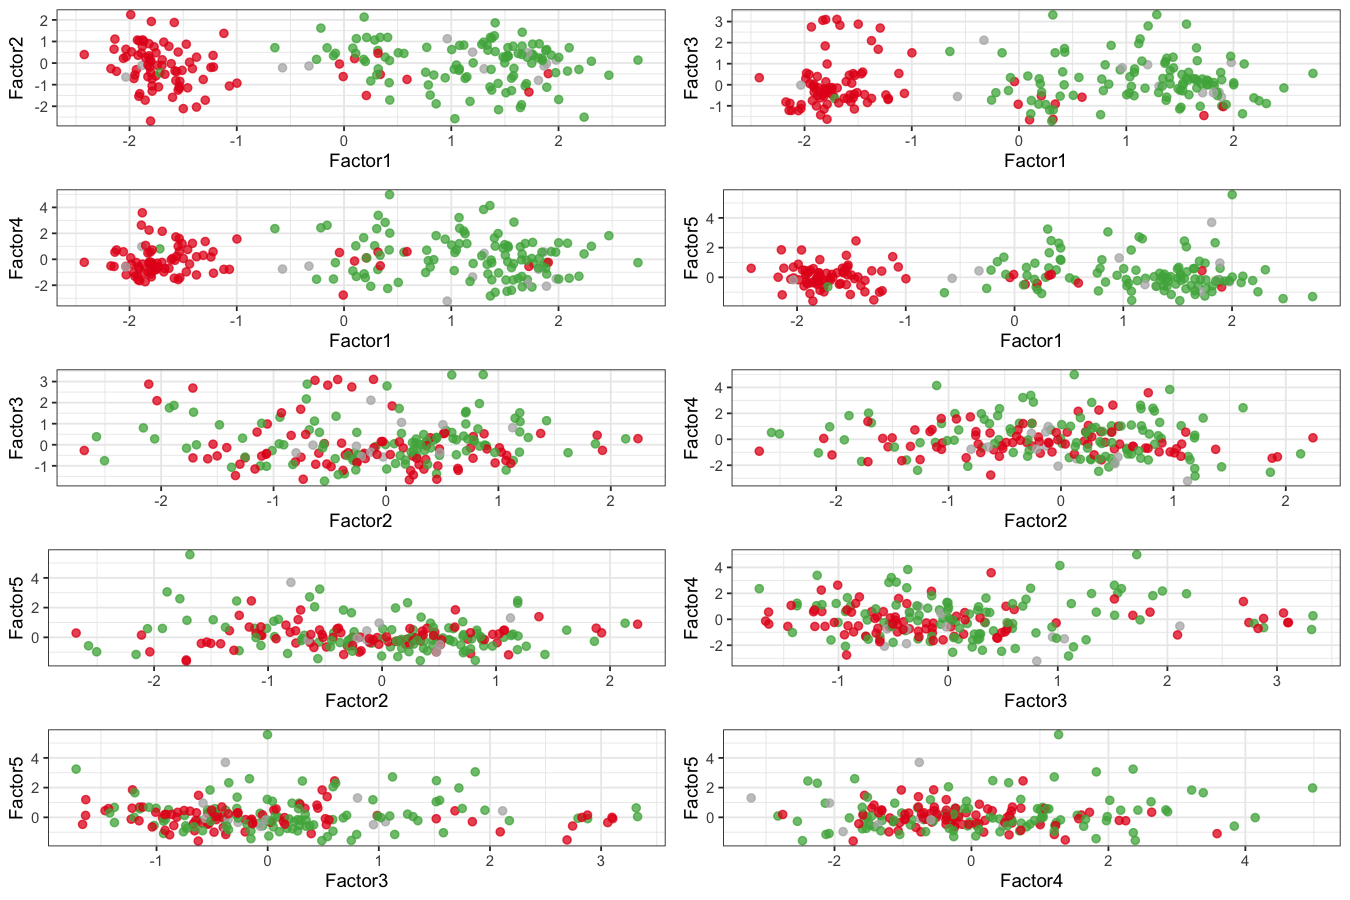

In [8]:
# Pairwise scatter matrix of Factors 1–5 to identify all major axes.
# Colour = IGHV status; reveals which factors capture distinct biology.

# Extract factor scores
Z <- get_factors(MOFAobject)[[1]]   # samples × factors matrix

# Factors 1–5 only for legibility
f_cols <- paste0("Factor", 1:min(5, ncol(Z)))
Z_top  <- as.data.frame(Z[, f_cols])
Z_top$IGHV <- meta$IGHV[match(rownames(Z_top), meta$sample)]

# Generate all pairs
pairs_data <- combn(f_cols, 2, simplify = FALSE)

scatter_plots <- map(pairs_data, function(pair) {
  ggplot(Z_top, aes(x = .data[[pair[1]]], y = .data[[pair[2]]], colour = IGHV)) +
    geom_point(size = 1.5, alpha = 0.75) +
    scale_colour_manual(values = ighv_colors, na.value = "grey70") +
    labs(x = pair[1], y = pair[2]) +
    theme_bw(base_size = 9) +
    theme(legend.position = "none")
})

plot_grid(plotlist = scatter_plots, ncol = 2)

---

## 4. Factor–Covariate Association Analysis

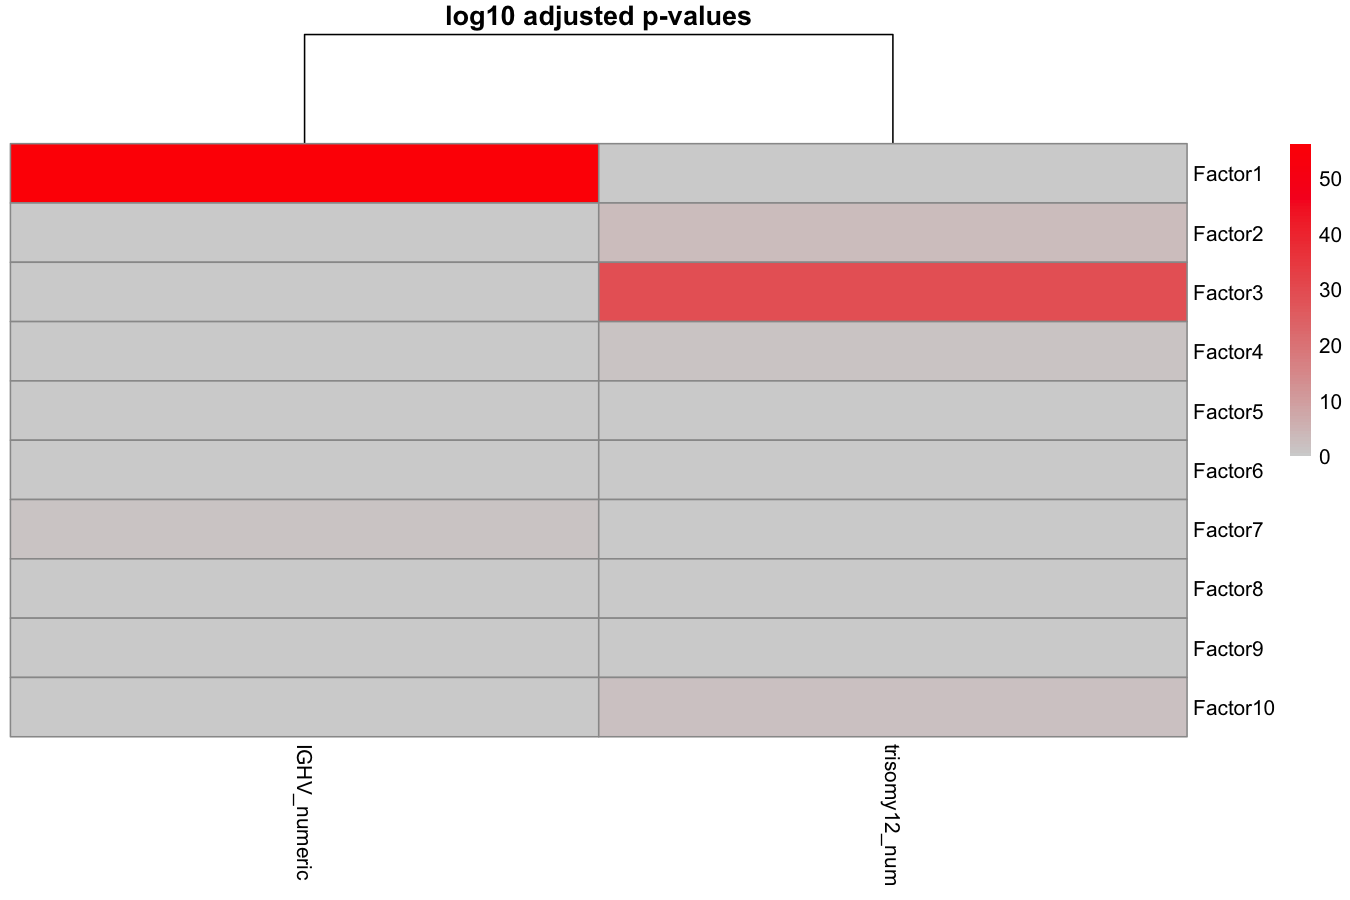

In [9]:
# correlate_factors_with_covariates() computes Spearman correlations between
# all factor scores and all numeric clinical variables, testing significance
# via permutation. Stars denote FDR-adjusted significance.
#
# Biological expectations:
#   Factor 1 ↔ IGHV_numeric    (strongest CLL prognostic marker)
#   Factor 2 ↔ trisomy12_num   (chromosomal dosage effects)
#   Factor 3+ ↔ treatment, TP53-del, age (secondary heterogeneity sources)

# Covariates must be numeric (already encoded in Notebook 2)
covariate_cols <- intersect(
  c("IGHV_numeric", "trisomy12_num", "died", "treatment"),
  colnames(meta)
)

if (length(covariate_cols) > 0) {
  correlate_factors_with_covariates(
    MOFAobject,
    covariates = covariate_cols,
    plot       = "log_pval"
  )
} else {
  message("No numeric covariates found. Check that Notebook 2 added metadata correctly.")
}

In [10]:
# Quantify Factor 1 vs IGHV association with Wilcoxon test
f1_scores <- get_factors(MOFAobject)[[1]][, 1]

test_df <- data.frame(
  sample = names(f1_scores),
  F1     = f1_scores
) |>
  left_join(meta[, c("sample", "IGHV")], by = "sample") |>
  filter(!is.na(IGHV))

wt <- wilcox.test(F1 ~ IGHV, data = test_df)
cat(sprintf(
  "Factor 1 ~ IGHV status  Wilcoxon W = %.0f,  p = %.2e\n",
  wt$statistic, wt$p.value
))

# Compute rank-biserial correlation as effect size
n_M <- sum(test_df$IGHV == "M")
n_U <- sum(test_df$IGHV == "U")
r_rb <- 1 - (2 * wt$statistic) / (n_M * n_U)
cat(sprintf("Rank-biserial correlation (effect size): r = %.3f\n", r_rb))

Factor 1 ~ IGHV status  Wilcoxon W = 8429,  p = 6.89e-28


Rank-biserial correlation (effect size): r = -0.930


---

## 5. Factor Correlation Matrix

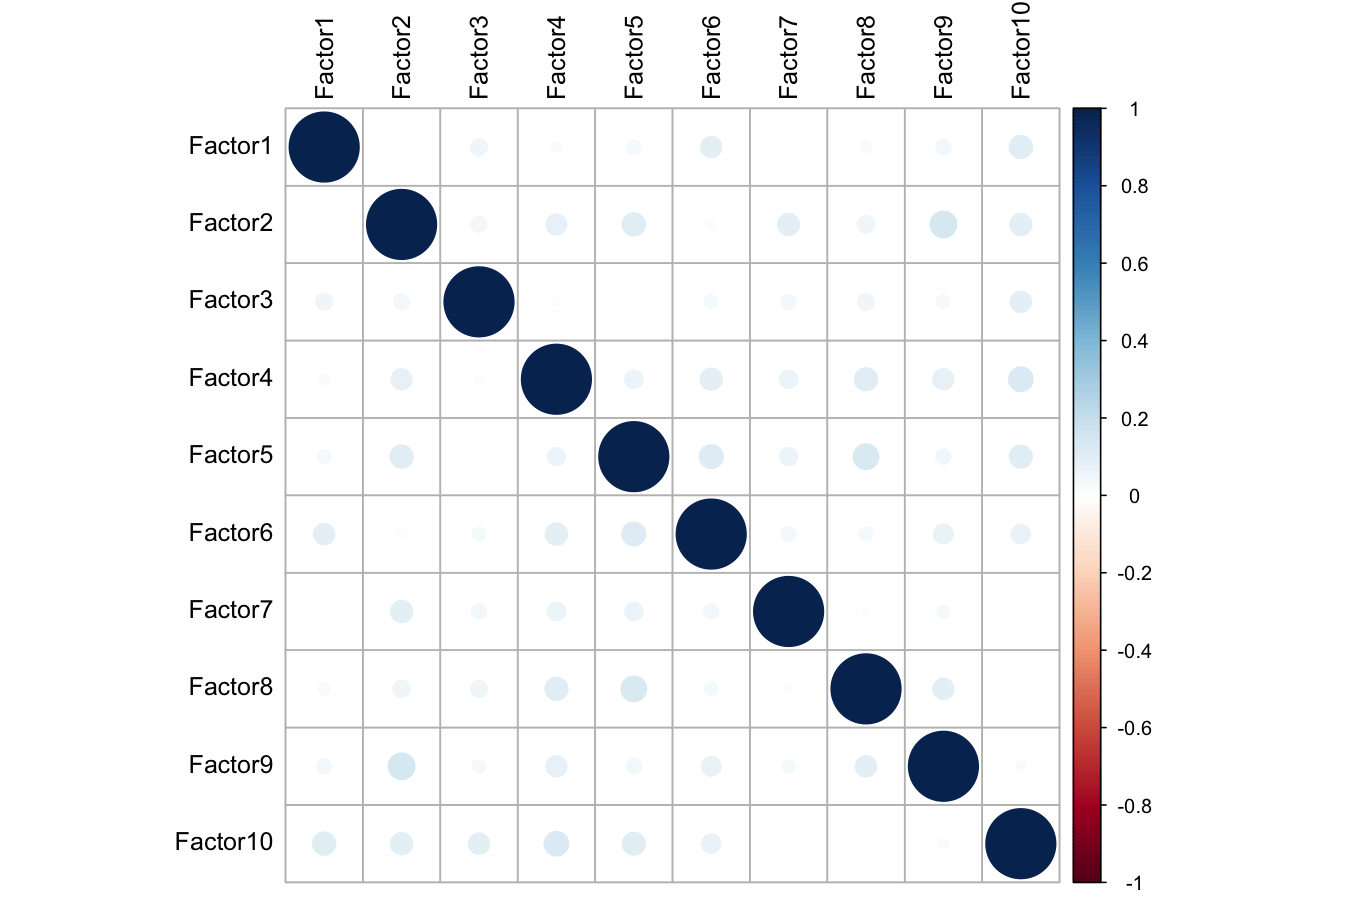

In [11]:
# MOFA+ factors are not constrained to be orthogonal (unlike PCA components).
# High correlation between two factors would indicate redundancy.
# All pairwise |r| should ideally be < 0.3 for a well-identified solution.

plot_factor_cor(MOFAobject)

---

## 6. Factor Scores Heatmap

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'MOFA+ Factor Scores — CLL patient landscape' in 'mbcsToSbcs': dot substituted for <e2>”


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'MOFA+ Factor Scores — CLL patient landscape' in 'mbcsToSbcs': dot substituted for <80>”


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'MOFA+ Factor Scores — CLL patient landscape' in 'mbcsToSbcs': dot substituted for <94>”


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'MOFA+ Factor Scores — CLL patient landscape' in 'mbcsToSbcs': dot substituted for <e2>”


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'MOFA+ Factor Scores — CLL patient landscape' in 'mbcsToSbcs': dot substituted for <80>”


...

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'MOFA+ Factor Scores — CLL patient landscape' in 'mbcsToSbcs': dot substituted for <80>”


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'MOFA+ Factor Scores — CLL patient landscape' in 'mbcsToSbcs': dot substituted for <94>”


Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'MOFA+ Factor Scores — CLL patient landscape' in 'mbcsToSbcs': dot substituted for <e2>”


Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'MOFA+ Factor Scores — CLL patient landscape' in 'mbcsToSbcs': dot substituted for <80>”


Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'MOFA+ Factor Scores — CLL patient landscape' in 'mbcsToSbcs': dot substituted for <94>”


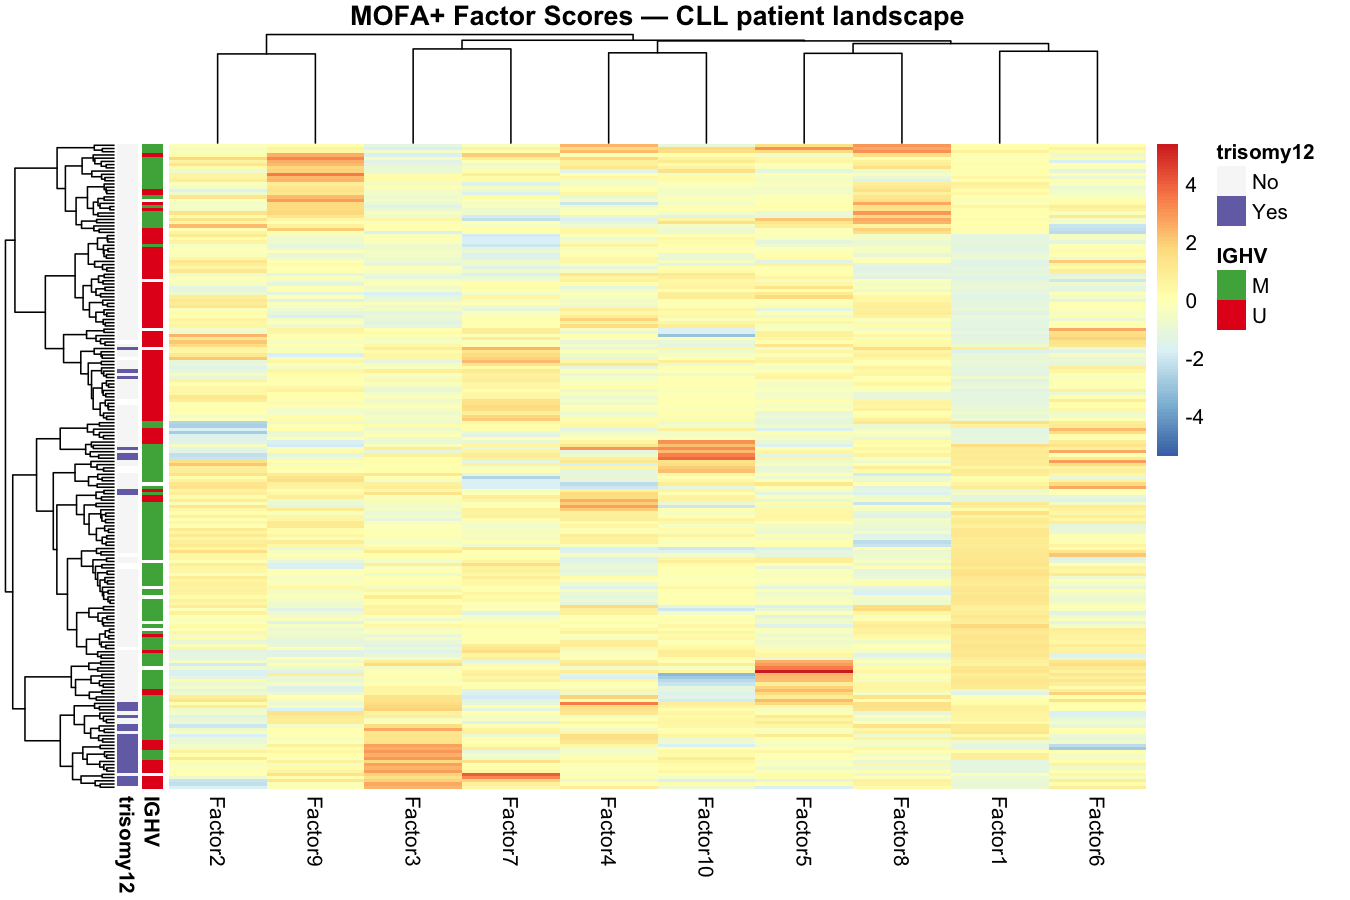

In [12]:
# Heatmap of Z (all patient factor scores), clustered by patient.
# Annotation by IGHV and trisomy 12 should align with clustering.

Z_mat <- get_factors(MOFAobject)[[1]]

anno_df <- meta |>
  select(sample, IGHV, trisomy12) |>
  tibble::column_to_rownames("sample") |>
  mutate(
    IGHV      = factor(IGHV, levels = c("M", "U")),
    trisomy12 = factor(trisomy12, levels = c(0, 1), labels = c("No", "Yes"))
  )

pheatmap(
  Z_mat[rownames(anno_df[rownames(anno_df) %in% rownames(Z_mat), ]), ],
  annotation_row  = anno_df,
  annotation_colors = list(
    IGHV      = ighv_colors,
    trisomy12 = trisomy_colors
  ),
  scale             = "column",
  clustering_method = "ward.D2",
  show_rownames     = FALSE,
  main              = "MOFA+ Factor Scores — CLL patient landscape",
  fontsize          = 10
)

---

## 7. Save Factor Analysis Results

In [13]:
# Save Z matrix and variance explained for Notebook 4
saveRDS(
  list(
    Z            = get_factors(MOFAobject)[[1]],
    r2           = get_variance_explained(MOFAobject)$r2_per_factor[[1]],
    meta         = meta
  ),
  "../../results/mofa/factor_analysis_results.RDS"
)

cat("Factor analysis results saved.\n")

Factor analysis results saved.


---

## Key Findings

| Factor | Primary biology | Evidence |
|--------|----------------|---------|
| **Factor 1** | IGHV mutational status | Wilcoxon p < 0.001; clear visual separation |
| **Factor 2** | Trisomy 12 | Visual cluster; Chr12 dosage expected |
| **Factor 3+** | Treatment, TP53, other | To be confirmed in Notebook 4 weights |

**Conclusion**: MOFA+ recovered IGHV mutational status as the dominant factor of
CLL patient variation — *without any clinical labels during training*. This demonstrates
that the multi-omics molecular signature of IGHV status is discoverable by unsupervised integration.

**→ Next: `04_biological_interpretation.Rmd`**